In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# تنظیمات برای نمایش بهتر نمودارها
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook")

# مسیر فایل (از دسکتاپ شما)
file_path = r"C:\Users\leila.gh\Desktop\perfectionism\perfectionism.xlsx"

# خواندن فایل
df_raw = pd.read_excel(file_path, header=0, engine='openpyxl')

# نمایش اطلاعات اولیه
print("شکل دیتا (تعداد سطر و ستون):", df_raw.shape)
df_raw.head()

شکل دیتا (تعداد سطر و ستون): (84, 110)


,پاسخنامه,شناسه پاسخ دهنده,1.لطفا جنسیت خود را مشخص کنید.,2. دانشجوی چه مقطعی هستید؟,1.هنگام مطالعه برای امتحان مرتبا رویاپردازی می کنم و تمرکز کردن برایم دشوار است.,2.تا لحظه ای که امکان داشته باشد آماده شدن برای امتحان را به تاخیر نمی اندازم.,3. سازمان دادن مطالب قبل از امتحان برایم دشوار است.,4.هنگامی که از تاریخ یک امتحان اطلاع پیدا می کنم اجازه نمی دهم که وقت تلف شود و فورا شروع به آماده شدن می کنم.,5.هنگامی که تاریخ یک امتحان نزدیک شود ،اماده شدن برای امتحان برایم دشوار است.,6.هنگامی که می بایست برای یک امتحان آماده شوم ،روی آن متمرکز می شوم و دچار حواس پرتی نمی شوم,...,10. هنگامی که سعی میکنم چیز جدیدی بیاموزم، اگر در ابتدا موفق نشوم به زودی آن را رها می کنم.,11. وقتی که مشکلات غیرمترقبه( ناگهانی/غیرقابل پیش بینی) رخ می دهد به خوبی از پس آن بر نمی آیم.,12. از یادگیری مطالب جدید هنگامی که به نظرم مشکل بیایند، اجتناب می کنم.,13. شکست باعث تلاش بیشتر من می شود.,14. به توانایی خود برای کارها اعتماد ندارم.,15. به خودم متکی هستم.,16. به سادگی تسلیم می شوم.,17. توانایی برخورد با اغلب مشکلاتی را که در زندگی برایم پیش می آید، ندارم.,تاریخ شروع,تاریخ اتمام
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,https://survey.porsline.ir/n/k/ziW8We7i/w20a?r...,w20a,زن,دکتری,اکثر اوقات,به ندرت,اکثر اوقات,به ندرت,اکثر اوقات,به ندرت,...,موافقم,مخالفم,تقریبا مخالفم,موافقم,مخالفم,موافقم,مخالفم,مخالفم,1402/03/09-08:00:17,1402/03/09-08:12:57
3,https://survey.porsline.ir/n/k/ziW8We7i/bVMv?r...,bVMv,زن,لیسانس,همیشه,اکثر اوقات,اکثر اوقات,هرگز,همیشه,به ندرت,...,تقریبا مخالفم,موافقم,کاملا موافقم,کاملا موافقم,کاملا مخالفم,کاملا موافقم,کاملا مخالفم,کاملا مخالفم,1402/03/09-00:49:41,1402/03/09-01:05:03
4,https://survey.porsline.ir/n/k/ziW8We7i/9OEQ?r...,9OEQ,زن,لیسانس,گهگاهی,اکثر اوقات,گهگاهی,هرگز,اکثر اوقات,گهگاهی,...,کاملا مخالفم,کاملا مخالفم,کاملا مخالفم,کاملا موافقم,کاملا مخالفم,کاملا موافقم,کاملا مخالفم,کاملا مخالفم,1402/03/09-00:08:13,1402/03/09-00:22:16


In [2]:
# حذف ردیف‌هایی که تمام مقادیرشان خالی است (NaN)
df_raw = df_raw.dropna(how='all')

# ستون‌های اولیه را نگه می‌داریم و بقیه را به عنوان پاسخ‌ها در نظر می‌گیریم
# ستون 0: لینک, 1: شناسه, 2: جنسیت, 3: مقطع تحصیلی
respondent_info = df_raw.iloc[:, :4].copy()  # اطلاعات دموگرافیک
responses = df_raw.iloc[:, 4:].copy()        # پاسخ‌های اصلی پرسشنامه

print("تعداد شرکت‌کنندگان:", len(respondent_info))
print("تعداد سوالات:", responses.shape[1])

تعداد شرکت‌کنندگان: 82
تعداد سوالات: 106


In [3]:
def map_likert_to_number(value):
    """
    Converts Farsi Likert-scale text to numeric values (1 to 5).
    Handles all variations (frequency, agreement, truthfulness).
    """
    if not isinstance(value, str):
        return np.nan
    
    # حذف فاصله‌های اضافی
    v = value.strip()
    
    # نگاشت کلی (عددی بالاتر = مثبت‌تر)
    mapping = {
        # Frequency (Procrastination) - مثبت بودنش بستگی به سوال دارد، ولی فعلاً عدد می‌دهیم
        'همیشه': 5, 'اکثر اوقات': 4, 'گهگاهی': 3, 'به ندرت': 2, 'هرگز': 1,
        'اکثراوقات': 4,  # تایپو در دیتا
        # Agreement (Perfectionism)
        'کاملا موافقم': 5, 'موافقم': 4, 'نمی دانم': 3, 'مخالفم': 2, 'کاملا مخالفم': 1,
        # Truthfulness (Resilience & Self-efficacy)
        'همیشه درست': 5, 'اغلب درست': 4, 'گاهی درست': 3, 'به ندرت درست': 2, 'کاملا نادرست': 1,
        'به ندرست درست': 2,  # تایپو
        'کاملا نادرست': 1
    }
    
    return mapping.get(v, np.nan)

# اعمال روی کل پاسخ‌ها
responses_numeric = responses.applymap(map_likert_to_number)

# بررسی: ببینیم چقدر داده تبدیل نشده باقی مانده (NaN)
print("تعداد سلول‌های تبدیل‌نشده:", responses_numeric.isna().sum().sum())

AttributeError: 'DataFrame' object has no attribute 'applymap'

In [ ]:
# بررسی دوباره ابعاد
print(responses_numeric.shape)  # خروجی: (تعداد نفرات, تعداد سوالات)

# تقسیم‌بندی بر اساس موقعیت ستون‌ها (به ترتیب در فایل):
# بخش تعلل‌ورزی (Procrastination): سوالات 1 تا 27 (ستون‌های 0 تا 26)
# بخش کمال‌گرایی (Perfectionism): سوالات 28 تا 62 (ستون‌های 27 تا 61)
# بخش تاب‌آوری (Resilience): سوالات 63 تا 87 (ستون‌های 62 تا 86)
# بخش خودکارآمدی (Self-efficacy): سوالات 88 تا 104 (ستون‌های 87 تا 103)

proc_cols = responses_numeric.iloc[:, 0:27]
perf_cols = responses_numeric.iloc[:, 27:62]
resil_cols = responses_numeric.iloc[:, 62:87]
selfeff_cols = responses_numeric.iloc[:, 87:104]

# محاسبه میانگین برای هر فرد
scores = pd.DataFrame()
scores['Procrastination'] = proc_cols.mean(axis=1)
scores['Perfectionism'] = perf_cols.mean(axis=1)
scores['Resilience'] = resil_cols.mean(axis=1)
scores['Self_Efficacy'] = selfeff_cols.mean(axis=1)

# اضافه کردن اطلاعات دموگرافیک
scores['Gender'] = respondent_info.iloc[:, 2].values
scores['Education'] = respondent_info.iloc[:, 3].values

# نمایش خلاصه
scores.describe()

In [ ]:
# 1. توزیع نمرات با هیستوگرام
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(['Procrastination', 'Perfectionism', 'Resilience', 'Self_Efficacy']):
    sns.histplot(scores[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of {col}', fontsize=14)
    axes[i].set_xlabel('Average Score (1-5)')
plt.tight_layout()
plt.savefig('score_distributions.png', dpi=300)  # ذخیره برای گیت‌هاب
plt.show()

# 2. مقایسه جنسیت (باکس‌پلات)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(x='Gender', y='Perfectionism', data=scores, ax=axes[0])
sns.boxplot(x='Gender', y='Procrastination', data=scores, ax=axes[1])
axes[0].set_title('Perfectionism by Gender')
axes[1].set_title('Procrastination by Gender')
plt.tight_layout()
plt.savefig('gender_comparison.png', dpi=300)
plt.show()

# 3. ماتریس همبستگی
plt.figure(figsize=(8, 6))
corr = scores[['Procrastination', 'Perfectionism', 'Resilience', 'Self_Efficacy']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Main Constructs', fontsize=16)
plt.savefig('correlation_matrix.png', dpi=300)
plt.show()

In [ ]:
from scipy.stats import ttest_ind, pearsonr

# تفاوت جنسیت در کمال‌گرایی
male_perf = scores[scores['Gender'] == 'مرد']['Perfectionism']
female_perf = scores[scores['Gender'] == 'زن']['Perfectionism']
t_stat, p_val = ttest_ind(male_perf, female_perf, nan_policy='omit')

print(f"T-test for Perfectionism (Male vs Female): t={t_stat:.3f}, p={p_val:.3f}")
if p_val < 0.05:
    print("✅ تفاوت معنادار است!")
else:
    print("❌ تفاوت معنادار نیست.")

# همبستگی بین تعلل و خودکارآمدی
corr_val, p_corr = pearsonr(scores['Procrastination'], scores['Self_Efficacy'])
print(f"Correlation Procrastination & Self-Efficacy: r={corr_val:.3f}, p={p_corr:.3f}")

In [5]:
import pandas as pd
import numpy as np

file_path = r"C:\Users\leila.gh\Desktop\perfectionism\perfectionism.xlsx"
df_raw = pd.read_excel(file_path, header=0, engine='openpyxl')
df_raw = df_raw.dropna(how='all')

respondent_info = df_raw.iloc[:, :4].copy()
responses = df_raw.iloc[:, 4:].copy()
print("✅ داده خوانده شد. شکل پاسخ‌ها:", responses.shape)

✅ داده خوانده شد. شکل پاسخ‌ها: (82, 106)


In [7]:
# به جای applymap از map استفاده می‌کنیم (مدرن و استاندارد جدید Pandas)
responses_numeric = responses.map(map_likert_to_number)
print("✅ تبدیل به عدد انجام شد. ابعاد:", responses_numeric.shape)

✅ تبدیل به عدد انجام شد. ابعاد: (82, 106)


In [8]:
# تقسیم به ۴ بخش
proc_raw = responses_numeric.iloc[:, 0:27]      # سوالات 1 تا 27
perf_raw = responses_numeric.iloc[:, 27:62]     # سوالات 28 تا 62
resil_raw = responses_numeric.iloc[:, 62:87]    # سوالات 63 تا 87
selfeff_raw = responses_numeric.iloc[:, 87:104] # سوالات 88 تا 104

# ---------- تصحیح سوالات معکوس در بخش تعلل‌ورزی ----------
# سوالات زوج (شماره 2,4,6,...,26) به این معنا هستند: "به تعویق نمی‌اندازم" 
# پس نمره 5 باید به 1 تبدیل شود و برعکس (فرمول: نمره جدید = 6 - نمره قدیم)

proc_reversed = proc_raw.copy()
# ایندکس‌های فرد (1,3,5,...,25) در پایتون یعنی سوالات شماره 2,4,6,...,26
even_indices = [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25]  
for col_idx in even_indices:
    proc_reversed.iloc[:, col_idx] = 6 - proc_reversed.iloc[:, col_idx]

# حالا همه سوالات تعلل همجهت هستند (نمره بالا = تعلل بالا)
proc_final = proc_reversed

# ---------- محاسبه نمره میانگین برای هر فرد ----------
scores = pd.DataFrame()
scores['Procrastination'] = proc_final.mean(axis=1)
scores['Perfectionism'] = perf_raw.mean(axis=1)
scores['Resilience'] = resil_raw.mean(axis=1)
scores['Self_Efficacy'] = selfeff_raw.mean(axis=1)

# اضافه کردن اطلاعات دموگرافیک (جنسیت و مقطع)
scores['Gender'] = respondent_info.iloc[:, 2].values
scores['Education'] = respondent_info.iloc[:, 3].values

# نمایش خلاصه آماری نمرات
print("📊 خلاصه نمرات محاسبه شده:")
display(scores.describe())

# نمایش ۵ نفر اول
print("\n🧑‍🎓 نمونه ۵ پاسخ‌دهنده اول:")
display(scores.head())

📊 خلاصه نمرات محاسبه شده:


,Procrastination,Perfectionism,Resilience,Self_Efficacy
count,81.000000,82.000000,81.000000,82.000000
mean,3.095828,3.572125,3.579259,3.173499
std,0.165498,0.438141,0.624824,0.589214
min,2.629630,2.285714,2.080000,2.176471
25%,3.000000,3.314286,3.080000,2.719048
50%,3.111111,3.514286,3.600000,3.088889
75%,3.222222,3.907143,4.000000,3.586364
max,3.518519,4.342857,5.000000,4.941176



🧑‍🎓 نمونه ۵ پاسخ‌دهنده اول:


,Procrastination,Perfectionism,Resilience,Self_Efficacy,Gender,Education
2,3.153846,3.942857,3.92,3.466667,زن,دکتری
3,3.037037,3.914286,4.12,3.500000,زن,لیسانس
4,2.851852,4.114286,4.36,2.235294,زن,لیسانس
5,3.259259,2.685714,3.44,2.687500,زن,فوق لیسانس
6,3.148148,3.657143,3.32,2.812500,مرد,لیسانس


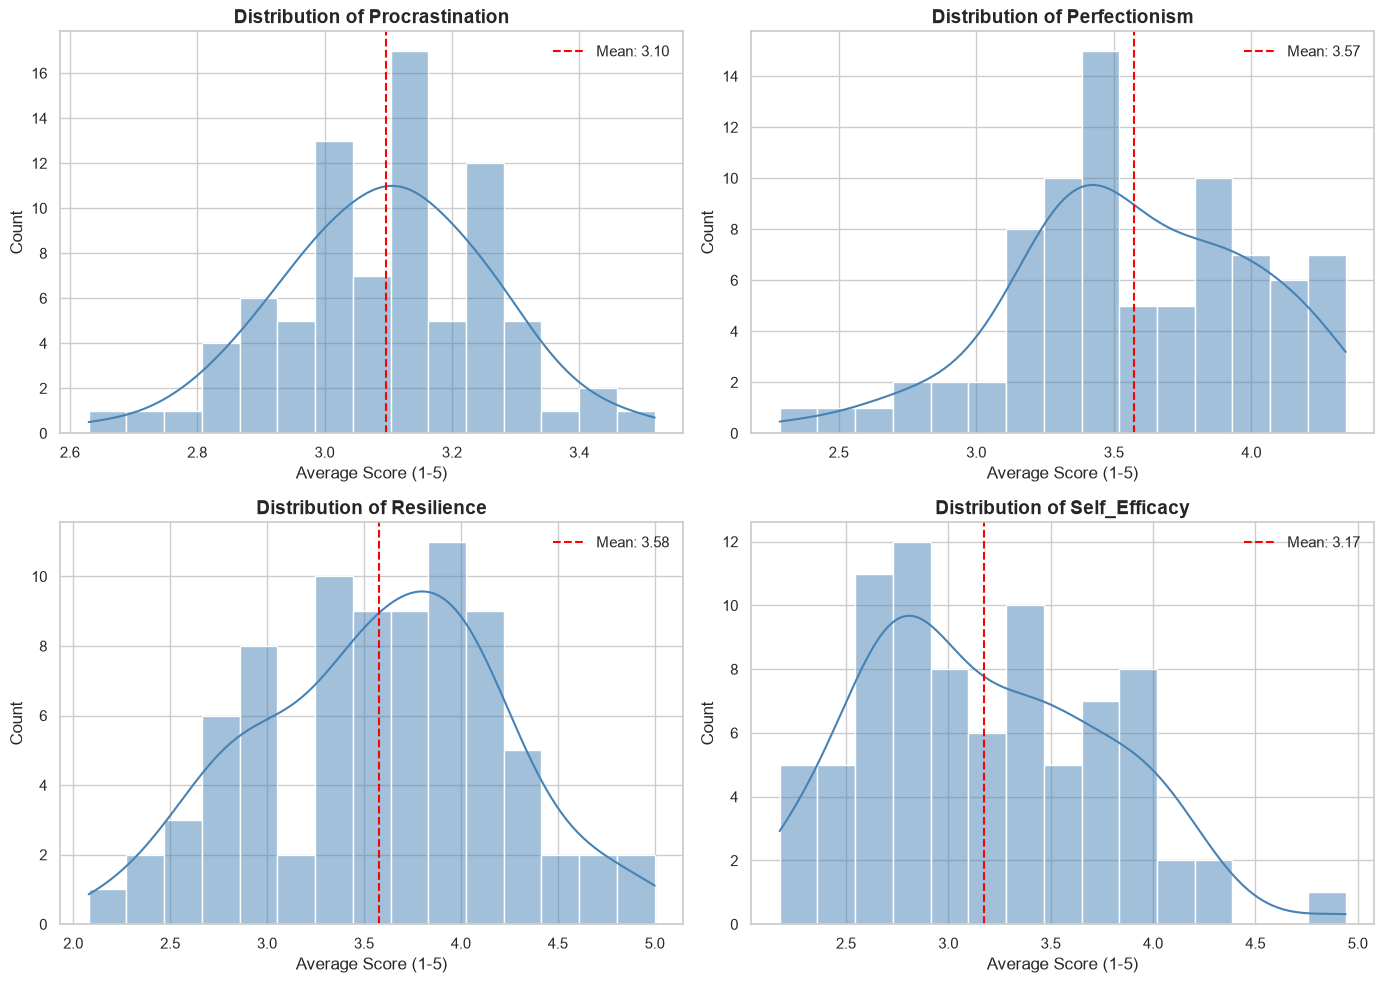

C:\Users\leila.gh\AppData\Local\Temp\ipykernel_7580\968286508.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Gender', y=col, data=scores, ax=axes[i], palette='Set2')
C:\Users\leila.gh\AppData\Local\Temp\ipykernel_7580\968286508.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Gender', y=col, data=scores, ax=axes[i], palette='Set2')
C:\Users\leila.gh\AppData\Local\Temp\ipykernel_7580\968286508.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Gender', y=col, data=scores, ax=axes[i], palette='Set2')
C:\Users\leila.gh\AppD

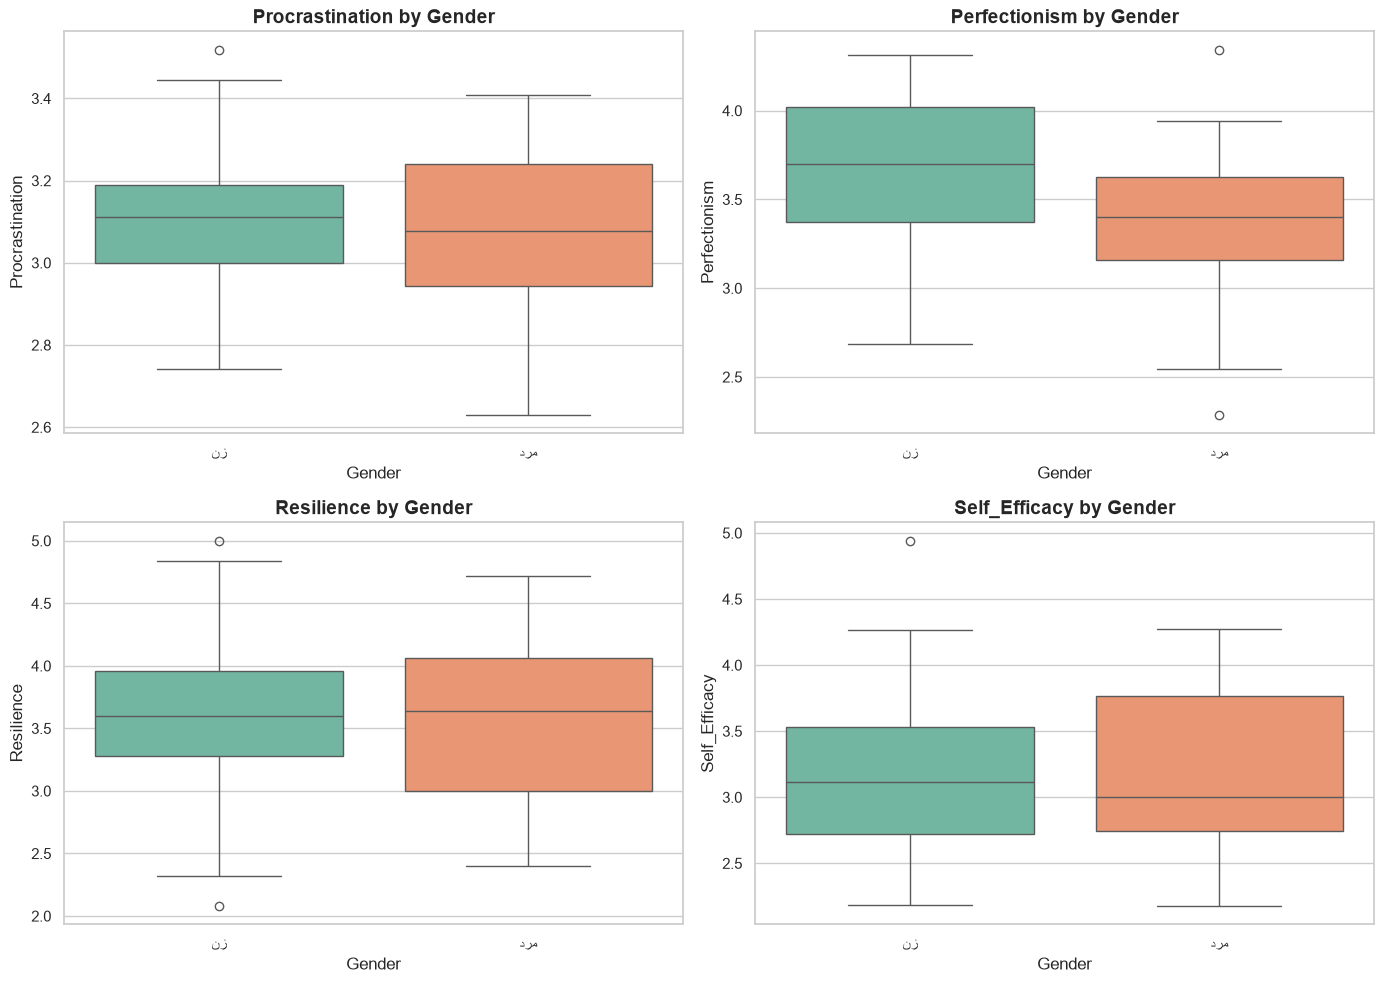

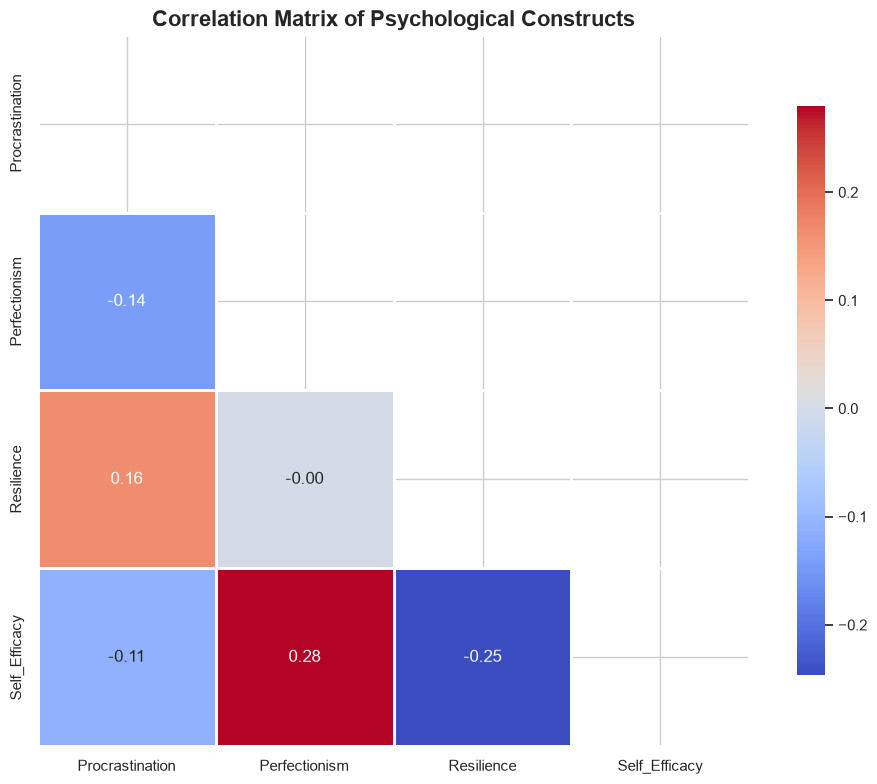

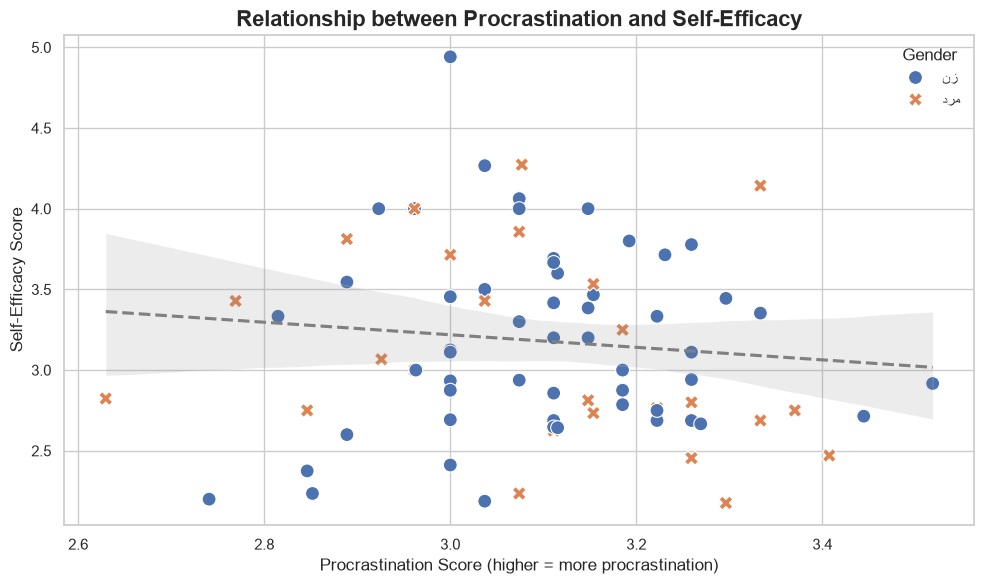

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# تنظیم استایل برای نمودارهای زیبا (مناسب رزومه)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# 1. توزیع نمرات (هیستوگرام + منحنی چگالی)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(['Procrastination', 'Perfectionism', 'Resilience', 'Self_Efficacy']):
    sns.histplot(scores[col], kde=True, ax=axes[i], color='steelblue', bins=15)
    axes[i].axvline(scores[col].mean(), color='red', linestyle='--', label=f'Mean: {scores[col].mean():.2f}')
    axes[i].set_title(f'Distribution of {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Average Score (1-5)')
    axes[i].legend()
plt.tight_layout()
plt.savefig('score_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. مقایسه جنسیت (Boxplot برای ۴ متغیر)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(['Procrastination', 'Perfectionism', 'Resilience', 'Self_Efficacy']):
    sns.boxplot(x='Gender', y=col, data=scores, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} by Gender', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Gender')
plt.tight_layout()
plt.savefig('gender_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. ماتریس همبستگی (نقشه حرارتی)
plt.figure(figsize=(10, 8))
corr = scores[['Procrastination', 'Perfectionism', 'Resilience', 'Self_Efficacy']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # فقط نیمه پایینی
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', fmt='.2f', 
            linewidths=1, square=True, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Psychological Constructs', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. نمودار پراکندگی (Scatter plot) – رابطه تعلل و خودکارآمدی
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Procrastination', y='Self_Efficacy', data=scores, hue='Gender', style='Gender', s=100)
sns.regplot(x='Procrastination', y='Self_Efficacy', data=scores, scatter=False, color='gray', line_kws={'linestyle':'--'})
plt.title('Relationship between Procrastination and Self-Efficacy', fontsize=16, fontweight='bold')
plt.xlabel('Procrastination Score (higher = more procrastination)')
plt.ylabel('Self-Efficacy Score')
plt.legend(title='Gender')
plt.tight_layout()
plt.savefig('scatter_proc_selfeff.png', dpi=300, bbox_inches='tight')
plt.show()

In [10]:
from scipy.stats import ttest_ind, pearsonr, f_oneway

# ---------- 1. آزمون تی‌تست برای مقایسه جنسیت ----------
print("=" * 50)
print("T-TEST: GENDER COMPARISONS")
print("=" * 50)

for col in ['Procrastination', 'Perfectionism', 'Resilience', 'Self_Efficacy']:
    male = scores[scores['Gender'] == 'مرد'][col].dropna()
    female = scores[scores['Gender'] == 'زن'][col].dropna()
    t, p = ttest_ind(male, female, equal_var=False)  # Welch's t-test
    print(f"{col:20s} | t = {t:.3f}, p = {p:.4f} {'✅' if p < 0.05 else '❌'}")

# ---------- 2. همبستگی پیرسون ----------
print("\n" + "=" * 50)
print("PEARSON CORRELATIONS")
print("=" * 50)
corr_matrix = scores[['Procrastination', 'Perfectionism', 'Resilience', 'Self_Efficacy']].corr()
for i in range(4):
    for j in range(i+1, 4):
        col1 = corr_matrix.columns[i]
        col2 = corr_matrix.columns[j]
        r = corr_matrix.iloc[i, j]
        # محاسبه p-value مجزا
        r_pearson, p_pearson = pearsonr(scores[col1], scores[col2])
        print(f"{col1:18s} & {col2:18s} | r = {r:.3f}, p = {p_pearson:.4f} {'✅' if p_pearson < 0.05 else '❌'}")

# ---------- 3. مقایسه مقاطع تحصیلی (ANOVA) ----------
print("\n" + "=" * 50)
print("ANOVA: EDUCATION LEVELS")
print("=" * 50)
edu_groups = scores.groupby('Education')
for col in ['Procrastination', 'Perfectionism', 'Resilience', 'Self_Efficacy']:
    groups = [group[col].dropna().values for name, group in edu_groups if len(group) > 1]
    if len(groups) >= 3:  # حداقل ۳ گروه برای ANOVA
        f, p = f_oneway(*groups)
        print(f"{col:20s} | F = {f:.3f}, p = {p:.4f} {'✅' if p < 0.05 else '❌'}")
    else:
        print(f"{col:20s} | Not enough groups for ANOVA")

T-TEST: GENDER COMPARISONS
Procrastination      | t = -0.342, p = 0.7338 ❌
Perfectionism        | t = -3.136, p = 0.0030 ✅
Resilience           | t = 0.030, p = 0.9759 ❌
Self_Efficacy        | t = -0.119, p = 0.9054 ❌

PEARSON CORRELATIONS
Procrastination    & Perfectionism      | r = -0.143, p = nan ❌
Procrastination    & Resilience         | r = 0.164, p = nan ❌
Procrastination    & Self_Efficacy      | r = -0.109, p = nan ❌
Perfectionism      & Resilience         | r = -0.000, p = nan ❌
Perfectionism      & Self_Efficacy      | r = 0.280, p = 0.0109 ✅
Resilience         & Self_Efficacy      | r = -0.247, p = nan ❌

ANOVA: EDUCATION LEVELS
Procrastination      | F = 0.530, p = 0.5904 ❌
Perfectionism        | F = 0.324, p = 0.7240 ❌
Resilience           | F = 0.267, p = 0.7661 ❌
Self_Efficacy        | F = 1.780, p = 0.1755 ❌


In [12]:
from scipy.stats import pearsonr
from itertools import combinations

print("\n" + "=" * 50)
print("PEARSON CORRELATIONS (سازگار با تمام نسخه‌ها)")
print("=" * 50)

vars_list = ['Procrastination', 'Perfectionism', 'Resilience', 'Self_Efficacy']

# ابتدا ببینیم چند نفر داده‌ی کامل دارند
print("🔍 تعداد داده‌های موجود برای هر متغیر:")
print(scores[vars_list].count())
print("\n" + "-" * 50)

for col1, col2 in combinations(vars_list, 2):
    # 1. یک دیتافریم موقت بسازید که فقط این دو ستون را دارد
    temp = scores[[col1, col2]]
    
    # 2. ردیف‌هایی که در هریک از این دو ستون NaN دارند را حذف کنید (Pairwise deletion)
    temp_clean = temp.dropna()
    
    # 3. اگر تعداد داده‌ها کمتر از ۳ باشد، همبستگی معتبر نیست
    if len(temp_clean) < 3:
        print(f"{col1:18s} & {col2:18s} | داده کافی نیست (N={len(temp_clean)})")
        continue
    
    # 4. محاسبه همبستگی
    r, p = pearsonr(temp_clean[col1], temp_clean[col2])
    print(f"{col1:18s} & {col2:18s} | r = {r:.3f}, p = {p:.4f} {'✅' if p < 0.05 else '❌'} (N={len(temp_clean)})")


PEARSON CORRELATIONS (سازگار با تمام نسخه‌ها)
🔍 تعداد داده‌های موجود برای هر متغیر:
Procrastination    81
Perfectionism      82
Resilience         81
Self_Efficacy      82
dtype: int64

--------------------------------------------------
Procrastination    & Perfectionism      | r = -0.143, p = 0.2029 ❌ (N=81)
Procrastination    & Resilience         | r = 0.164, p = 0.1444 ❌ (N=81)
Procrastination    & Self_Efficacy      | r = -0.109, p = 0.3314 ❌ (N=81)
Perfectionism      & Resilience         | r = -0.000, p = 0.9982 ❌ (N=81)
Perfectionism      & Self_Efficacy      | r = 0.280, p = 0.0109 ✅ (N=82)
Resilience         & Self_Efficacy      | r = -0.247, p = 0.0264 ✅ (N=81)


In [13]:
# فرض: همه سوالات تاب‌آوری معکوس هستند (معمولاً در پرسشنامه‌های فارسی اینطور است)
resil_reversed = 6 - resil_raw   # چون نمرات 1 تا 5 هستند
scores['Resilience_Corrected'] = resil_reversed.mean(axis=1)

# محاسبه همبستگی مجدد
r_new, p_new = pearsonr(scores['Resilience_Corrected'], scores['Self_Efficacy'])
print(f"همبستگی تاب‌آوری اصلاح‌شده با خودکارآمدی: r = {r_new:.3f}, p = {p_new:.4f}")

همبستگی تاب‌آوری اصلاح‌شده با خودکارآمدی: r = nan, p = nan


In [14]:
# ساخت نمره‌ی تصحیح‌شده‌ی تاب‌آوری (با فرض معکوس بودن همه‌ی سوالات)
resil_reversed = 6 - resil_raw
scores['Resilience_Corrected'] = resil_reversed.mean(axis=1)

# حذف ردیف‌هایی که در یکی از این دو ستون، مقدار NaN دارند
temp_df = scores[['Resilience_Corrected', 'Self_Efficacy']].dropna()

# بررسی اینکه آیا داده‌ی کافی داریم
if len(temp_df) >= 3:
    r_new, p_new = pearsonr(temp_df['Resilience_Corrected'], temp_df['Self_Efficacy'])
    print(f"همبستگی تاب‌آوری اصلاح‌شده با خودکارآمدی: r = {r_new:.3f}, p = {p_new:.4f}")
else:
    print("تعداد نمونه‌های کامل برای محاسبه‌ی همبستگی کافی نیست.")

همبستگی تاب‌آوری اصلاح‌شده با خودکارآمدی: r = 0.247, p = 0.0264


In [15]:
print("تعداد NaN در نمره‌ی اصلاح‌شده‌ی تاب‌آوری:", scores['Resilience_Corrected'].isna().sum())
print("تعداد NaN در خودکارآمدی:", scores['Self_Efficacy'].isna().sum())

تعداد NaN در نمره‌ی اصلاح‌شده‌ی تاب‌آوری: 1
تعداد NaN در خودکارآمدی: 0


In [16]:
# ساخت نمره‌ی تصحیح‌شده‌ی تاب‌آوری (با فرض معکوس بودن همه‌ی سوالات)
resil_reversed = 6 - resil_raw
scores['Resilience_Corrected'] = resil_reversed.mean(axis=1)

# حذف ردیف‌های NaN (فقط ۱ مورد)
temp_df = scores[['Resilience_Corrected', 'Self_Efficacy']].dropna()

# محاسبه همبستگی
r_new, p_new = pearsonr(temp_df['Resilience_Corrected'], temp_df['Self_Efficacy'])
print(f"✅ همبستگی تاب‌آوری اصلاح‌شده با خودکارآمدی: r = {r_new:.3f}, p = {p_new:.4f}")

✅ همبستگی تاب‌آوری اصلاح‌شده با خودکارآمدی: r = 0.247, p = 0.0264
